# Exploring the Battery Storage Environment

This notebook explores the battery storage environment and trains a PPO agent.

In [23]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))
sys.path.insert(0, str(project_root / "01_workshop"))

import numpy as np
import matplotlib.pyplot as plt
from battery_env_solution_David import BatteryStorageEnv

EPISODE_LENGTH = 730  # 1 month episodes
ENABLE_DEGRADATION = True  # enable capacity degradation for testing

## 1. Environment Overview

In [24]:
# Create environment
env = BatteryStorageEnv(episode_length=EPISODE_LENGTH, enable_degradation=ENABLE_DEGRADATION)  

print("=== Battery Storage Environment ===")
print(f"Capacity: {env.capacity} kWh")
print(f"Max charge rate: {env.max_charge_rate} kW")
print(f"Episode length: {env.episode_length} steps")
print(f"Degradation: {env.enable_degradation}")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(f"\nData split:")
print(f"  Total episodes: {env.n_episodes}")
print(f"  Available episodes: {env._available_episodes}")

=== Battery Storage Environment ===
Capacity: 10.0 kWh
Max charge rate: 2.5 kW
Episode length: 730 steps
Degradation: True
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(0.0, 1.0, (13,), float32)

Data split:
  Total episodes: 35
  Available episodes: (0, 29)


## 2. Running Episodes

In [ ]:
def run_episode(env, policy="random", seed=42, thresholds=(0.2, 0.5)):
    """Run a single episode and collect data.
    
    Args:
        thresholds: tuple of (charge_threshold, discharge_threshold) as fractions
                    of env.price_max. E.g. (0.2, 0.5) means charge below 20% of
                    max price, discharge above 50% of max price.
    """
    obs, info = env.reset(seed=seed)
    
    data = {
        "soc": [info["soc"]],
        "price": [info["price"]],
        "load": [info["load"]],
        "action": [],
        "reward": [],
        "grid_energy": [],
    }
    
    total_reward = 0
    done = False

    # Convert normalized thresholds to actual prices
    threshold_min = thresholds[0] * env.price_max
    threshold_max = thresholds[1] * env.price_max
    
    while not done:
        # Select action based on policy
        if policy == "random":
            action = env.action_space.sample()
        elif policy == "do_nothing":
            action = np.array([0.0], dtype=np.float32)
        elif policy == "simple_heuristic":
            # Use info dict for named access (robust to observation layout changes)
            price = info["price"]
            if price < threshold_min:
                action = np.array([1.0], dtype=np.float32)   # charge when cheap
            elif price > threshold_max:
                action = np.array([-1.0], dtype=np.float32)  # discharge when expensive
            else:
                action = np.array([0.0], dtype=np.float32)
        else:
            action = policy(obs)
        
        # Store old SoC to calculate actual charge power
        old_soc = env.soc
        load = info["load"]
        
        # Take step
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Calculate ACTUAL charge power from SoC change (not intended action)
        actual_charge_power = env.soc - old_soc
        
        # Calculate ACTUAL grid energy (clamped to 0, can't sell back)
        grid_energy = max(0, load + actual_charge_power)
        
        # Store data
        data["action"].append(action[0])
        data["reward"].append(reward)
        data["grid_energy"].append(grid_energy)
        
        if not done:
            data["soc"].append(info["soc"])
            data["price"].append(info["price"])
            data["load"].append(info["load"])
        
        total_reward += reward
    
    return data, total_reward

## 3. Visualization

In [26]:
def plot_episode(data, title="Episode", xlim=None, price_max=None, thresholds=(0.2, 0.5)):
    """Plot episode data.
    
    Args:
        thresholds: tuple of (charge_threshold, discharge_threshold) as fractions of price_max
        price_max: maximum price for converting normalized thresholds to actual prices
    """
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    hours = np.arange(len(data["price"]))
    
    # Price
    axes[0].plot(hours, data["price"], "b-", linewidth=0.8)
    axes[0].set_ylabel("Price (€/kWh)")
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    
    # Add threshold lines if provided
    if thresholds and price_max:
        charge_thresh, discharge_thresh = thresholds
        axes[0].axhline(y=charge_thresh * price_max, color="green", linestyle="--", 
                        alpha=0.7, label=f"Charge below {charge_thresh * price_max:.2f} €/kWh")
        axes[0].axhline(y=discharge_thresh * price_max, color="red", linestyle="--", 
                        alpha=0.7, label=f"Discharge above {discharge_thresh * price_max:.2f} €/kWh")
        axes[0].legend(loc="upper right")
    
    # Load and grid energy
    axes[1].plot(hours, data["load"], "orange", linewidth=0.8, label="Load")
    axes[1].plot(hours, data["grid_energy"], "red", linewidth=0.8, alpha=0.7, label="Grid Energy")
    axes[1].axhline(y=0, color="black", linestyle="--", alpha=0.3)
    axes[1].set_ylabel("Energy (kWh)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # State of charge
    axes[2].plot(hours, data["soc"], "g-", linewidth=0.8)
    axes[2].axhline(y=10, color="red", linestyle="--", alpha=0.5, label="Capacity")
    axes[2].set_ylabel("SoC (kWh)")
    axes[2].set_ylim(0, 11)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Actions
    colors = ["green" if a > 0 else "red" if a < 0 else "gray" for a in data["action"]]
    axes[3].bar(hours, data["action"], color=colors, alpha=0.7, width=1.0)
    axes[3].set_ylabel("Action")
    axes[3].set_ylim(-1.1, 1.1)
    axes[3].axhline(y=0, color="black", linestyle="-", alpha=0.3)
    axes[3].grid(True, alpha=0.3)
    
    # Accumulated savings (baseline cost - actual cost)
    baseline_cost = np.cumsum(np.array(data["price"]) * np.array(data["load"]))
    actual_cost = np.cumsum(-np.array(data["reward"]))
    savings = baseline_cost - actual_cost
    axes[4].plot(hours, savings, "g-", linewidth=0.8)
    axes[4].axhline(y=0, color="black", linestyle="--", alpha=0.3)
    axes[4].fill_between(hours, 0, savings, where=savings >= 0, alpha=0.2, color="green")
    axes[4].fill_between(hours, 0, savings, where=savings < 0, alpha=0.2, color="red")
    axes[4].set_ylabel("Savings (€)")
    axes[4].set_xlabel("Hour")
    axes[4].grid(True, alpha=0.3)
    
    # Day markers as x-axis ticks
    day_ticks = np.arange(0, len(data["price"]), 24)
    axes[4].set_xticks(day_ticks)
    axes[4].set_xticklabels([f"Day {i//24 + 1}" for i in day_ticks], rotation=45)
    
    if xlim:
        for ax in axes:
            ax.set_xlim(xlim)
    
    plt.tight_layout()
    return fig

## 4. Policy Comparison

In [27]:
policies = ["do_nothing", "random", "simple_heuristic"]

# True "no battery" baseline: what you'd pay buying everything from the grid
# Computed directly from data, unaffected by reward shaping or degradation penalties
start, end = env._available_episodes
baseline_cost = np.mean(np.sum(env.prices[start:end] * env.loads[start:end], axis=1))

print("Policy Comparison (10 episodes each):")
print("=" * 50)

for policy in policies:
    rewards = [run_episode(env, policy=policy, seed=seed)[1] for seed in range(10)]
    cost_mean = -np.mean(rewards)
    cost_std = np.std(rewards)
    print(f"{policy:20s}: {cost_mean:7.2f} ± {cost_std:5.2f} € (saved cost: {baseline_cost - cost_mean:6.2f} €)")

Policy Comparison (10 episodes each):
do_nothing          :  184.02 ± 35.68 € (saved cost: -27.42 €)
random              :  235.17 ±  5.56 € (saved cost: -78.57 €)
simple_heuristic    :  164.11 ±  5.85 € (saved cost:  -7.52 €)


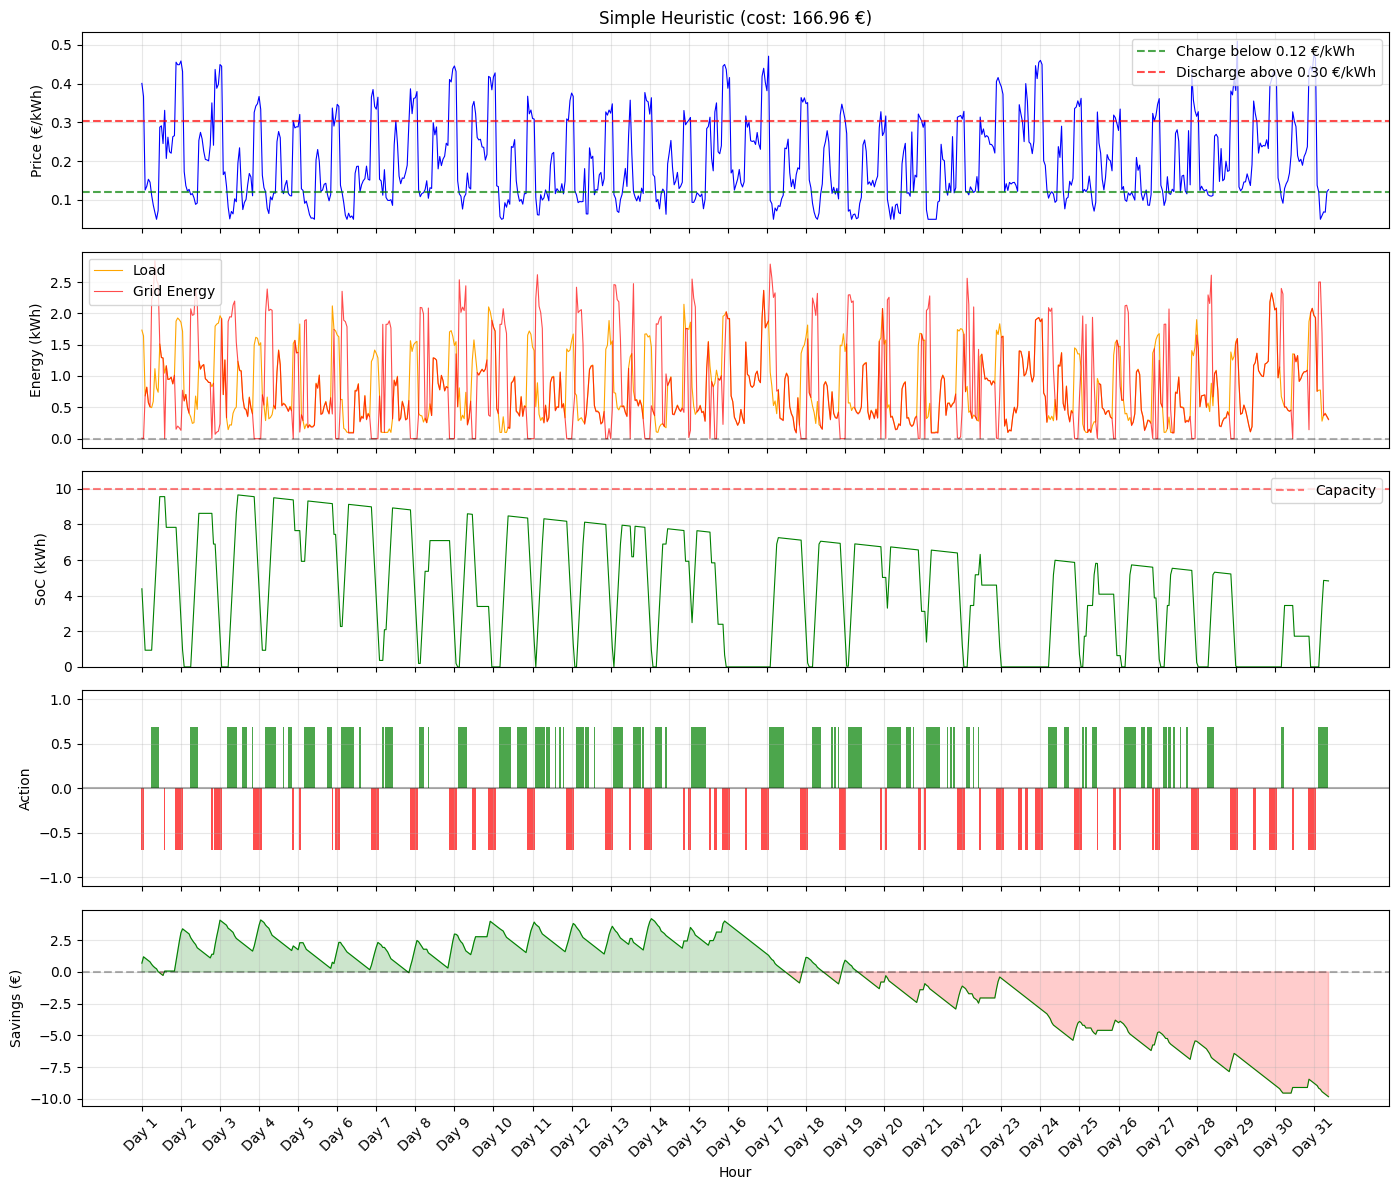

In [28]:
# Visualize simple heuristic with threshold lines
# Thresholds: charge when price < 20% of max, discharge when price > 50% of max
data, reward = run_episode(env, policy="simple_heuristic", seed=42)
fig = plot_episode(
    data, 
    f"Simple Heuristic (cost: {-reward:.2f} €)",
    price_max=env.price_max,
)
plt.show()

## 5. Train PPO Agent

In [18]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# Use train/eval split to avoid data leakage
def make_train_env():
    return BatteryStorageEnv(split="train", episode_length=EPISODE_LENGTH, enable_degradation=ENABLE_DEGRADATION)

def make_eval_env():
    return BatteryStorageEnv(split="eval", episode_length=EPISODE_LENGTH, enable_degradation=ENABLE_DEGRADATION)

train_env = make_vec_env(make_train_env, n_envs=4)
eval_env = make_eval_env()

# Show split info
train_info = BatteryStorageEnv(split="train", episode_length=EPISODE_LENGTH, enable_degradation=ENABLE_DEGRADATION)
print(f"Train episodes: {train_info._available_episodes}")
print(f"Eval episodes:  {eval_env._available_episodes}")
train_info.close()

model = PPO("MlpPolicy", train_env, verbose=0)

Train episodes: (0, 29)
Eval episodes:  (29, 35)


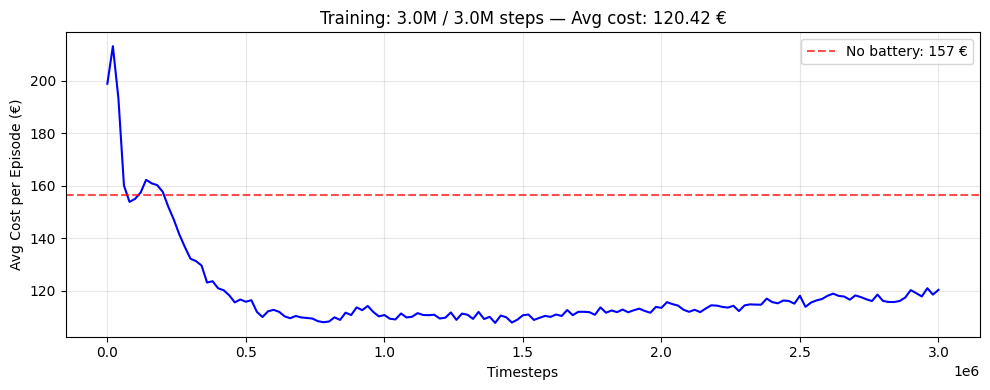

Baseline (no battery): 156.55 €
Before training: 198.80 €
After training:  120.42 €
Improvement:     36.13 € (23.1%)


In [ ]:
from utils import LiveEvalCallback

TOTAL_TIMESTEPS = int(1.5e6)

# True "no battery" baseline from eval data (unaffected by reward shaping)
start, end = eval_env._available_episodes
baseline_cost = np.mean(np.sum(eval_env.prices[start:end] * eval_env.loads[start:end], axis=1))

# LiveEvalCallback periodically pauses training, runs eval episodes, and
# redraws a live cost curve in this cell. See 01_workshop/utils.py for details.
callback = LiveEvalCallback(
    eval_env=eval_env,       # held-out eval environment (split="eval")
    eval_freq=20_000,        # evaluate every eval_freq training steps
    baseline_cost=baseline_cost,  # horizontal reference line on the plot
)

# Start training. We don't use progress_bar=True here because our callback's
# clear_output() would repeatedly wipe it, causing flicker. The plot title
# already shows the current step count as a progress indicator.
print(f"Training PPO for {TOTAL_TIMESTEPS/1e3:.0f}k steps...")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)

# Training summary using the data recorded by the callback
cost_before = -callback.mean_rewards[0]  # first eval point = untrained policy
cost_after = -callback.mean_rewards[-1]   # last eval point = trained policy

print("Baseline (no battery): {:.2f} €".format(baseline_cost))
print(f"Before training: {cost_before:.2f} €")
print(f"After training:  {cost_after:.2f} €")
print(f"Improvement:     {baseline_cost - cost_after:.2f} € ({100 * (baseline_cost - cost_after) / baseline_cost:.1f}%)")

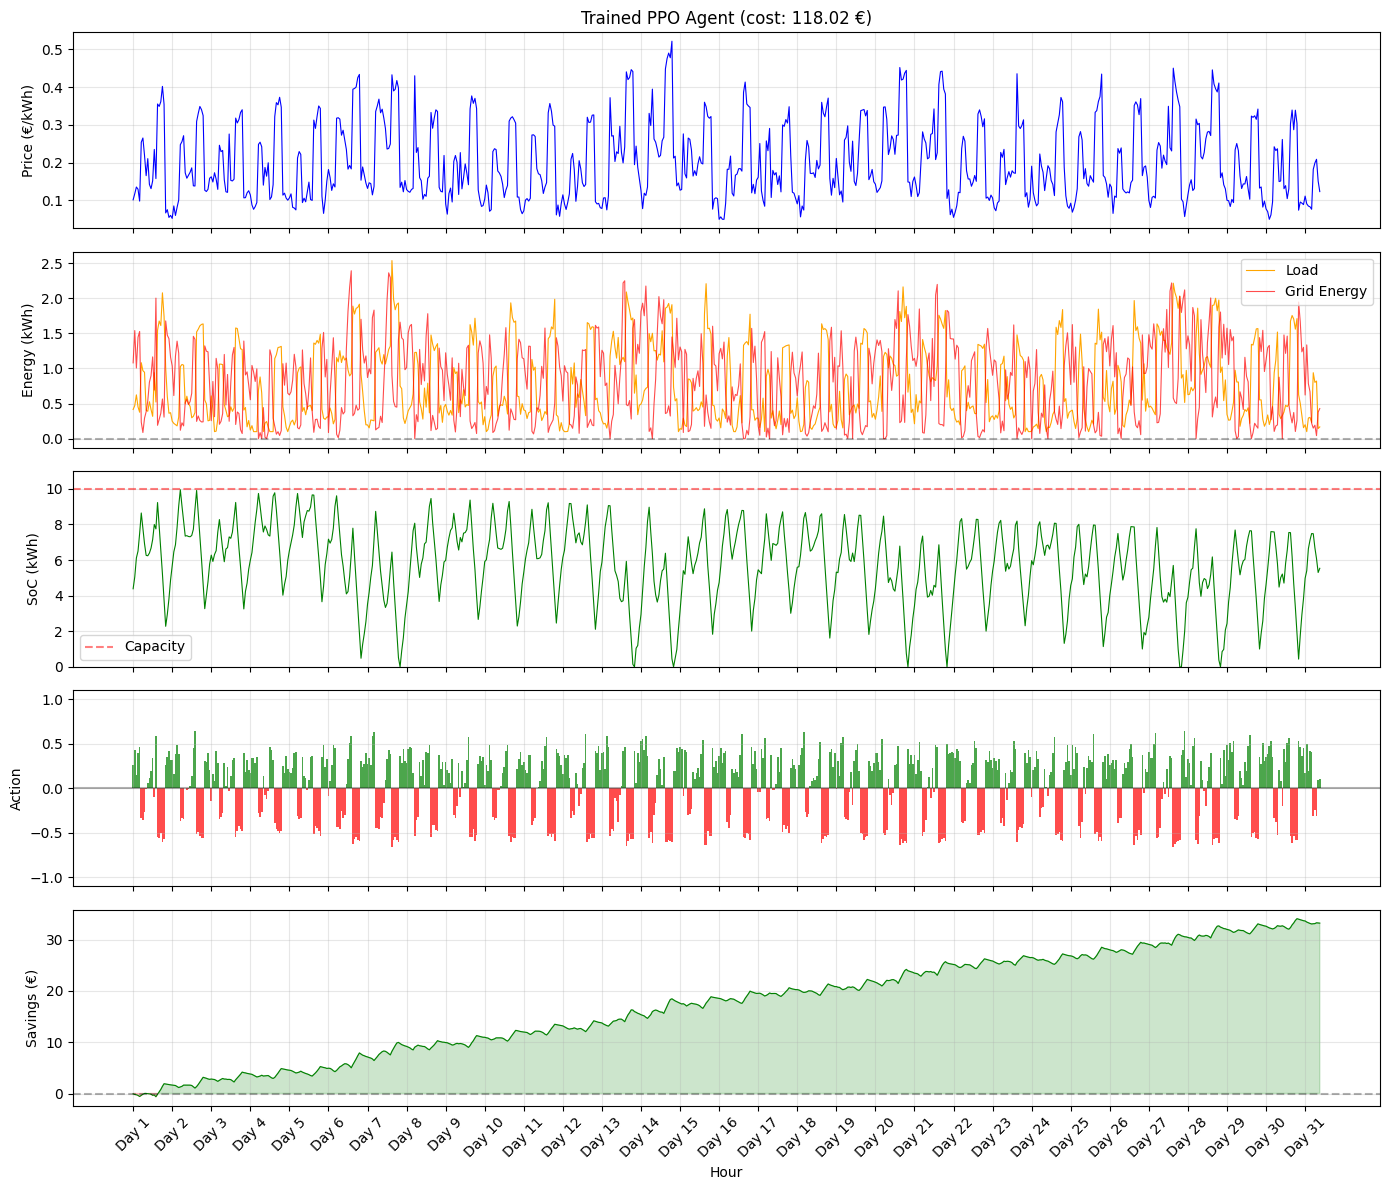

In [20]:
data_ppo, reward_ppo = run_episode(eval_env, policy=lambda obs: model.predict(obs, deterministic=True)[0], seed=42)
fig = plot_episode(data_ppo, f"Trained PPO Agent (cost: {-reward_ppo:.2f} €)")
plt.show()

In [21]:
eval_env_compare = make_eval_env()

# Run all policies over 100 episodes
policies = {
    "No battery": "do_nothing",
    "Heuristic": "simple_heuristic",
    "PPO": lambda obs: model.predict(obs, deterministic=True)[0],
}

results = {}
for name, policy in policies.items():
    rewards = [run_episode(eval_env_compare, policy=policy, seed=seed)[1] for seed in range(100)]
    results[name] = {"cost": -np.mean(rewards), "std": np.std(rewards)}

# True "no battery" baseline from eval data (unaffected by reward shaping)
start, end = eval_env_compare._available_episodes
baseline_cost = np.mean(np.sum(eval_env_compare.prices[start:end] * eval_env_compare.loads[start:end], axis=1))

print("Final Comparison (100 eval episodes)")
print("=" * 60)
print(f"{'Policy':<15} {'Avg Cost (€)':>15} {'Savings (€)':>15} {'Savings (%)':>15}")
print("-" * 60)
for name, r in results.items():
    savings = baseline_cost - r["cost"]
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<15} {r['cost']:>11.2f} ± {r['std']:.2f} {savings:>+11.2f} {pct:>+14.1f}%")

eval_env_compare.close()

Final Comparison (100 eval episodes)
Policy             Avg Cost (€)     Savings (€)     Savings (%)
------------------------------------------------------------
No battery           181.04 ± 33.18      -24.48          -15.6%
Heuristic            203.95 ± 3.62      -47.40          -30.3%
PPO                  121.03 ± 2.58      +35.52          +22.7%


In [22]:
# Cleanup
train_env.close()
eval_env.close()
eval_env_compare.close()